In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks 
from scipy.optimize import curve_fit
from matplotlib.ticker import FuncFormatter

plt.style.use("seaborn-v0_8")

fontsize = 15
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)

colores  = {
    "blue":   "#4C72B0",
    "green":  "#55A868",
    "red":    "#C44E52",
    "purple": "#8172B2",
    "yellow": "#CCB974",
    "cyan":   "#64B5CD",
}

In [2]:
def leer_archivo(L, f, p, ventana, counter):
    L_text = f"_L{L:.1f}" if L != 6.2 else ""
    nombre_archivo = f"laser_chopper{L_text}_f{f:.0f}_p{p:.2f}_{ventana}_{counter}.csv"
    ruta = "../datos/" + nombre_archivo

    df = pd.read_csv(ruta)
    return df

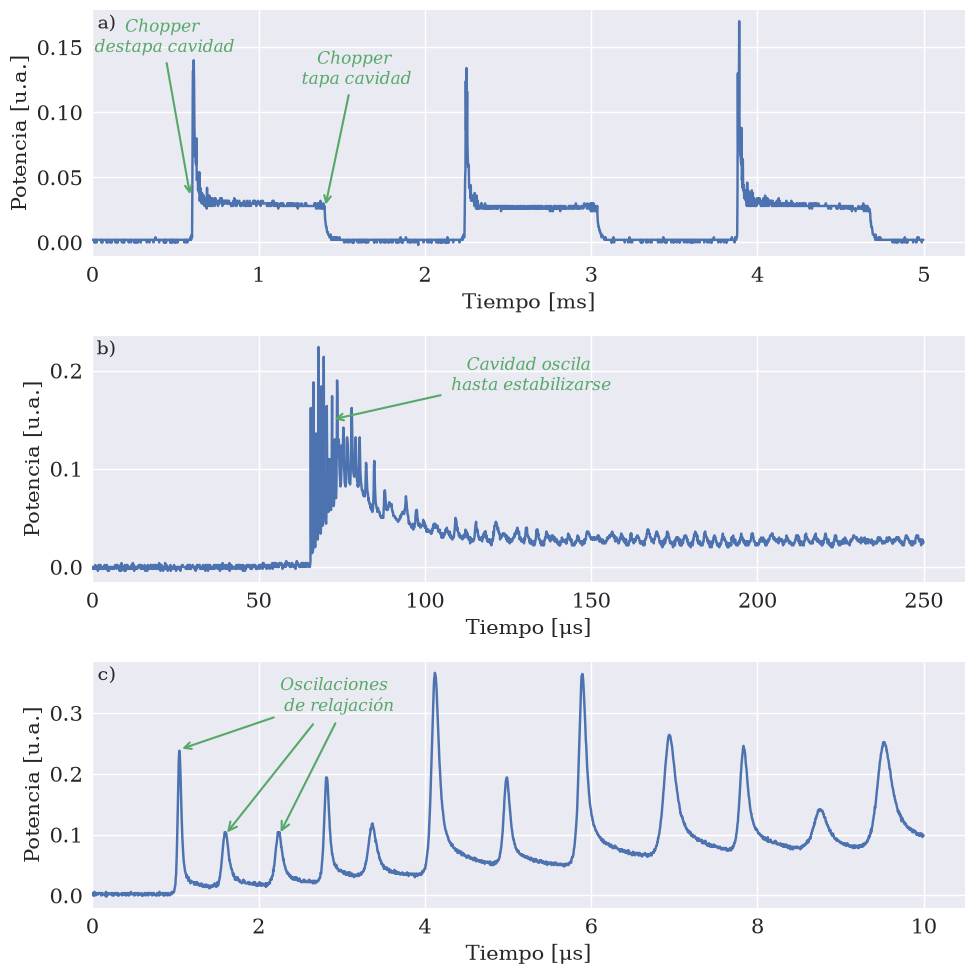

In [3]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import pandas as pd

formato_micro = FuncFormatter(lambda x, pos: f"{x * 1e6:g}")
formato_mili = FuncFormatter(lambda x, pos: f"{x * 1e3:g}")

L = 6.2  # Largo cavidad cm
f = 610  # Frecuencia Hz
p = 2.38  # potencia (corriente al laser en A)
ventana = "s"
counter = 3

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
axs = axs[::-1]
dfs = [
    leer_archivo(L, f, p, ventana, counter)
    for ventana in ("s", "pc", "v")
]

unidades_tiempo = ["$\\mu$s", "$\\mu$s", "ms"]

# ============================================================
# GRAFICAR Y REAJUSTAR TIEMPOS A CERO
# ============================================================
t_min_list = []  # Para guardar los desfases de cada panel y corregir anotaciones

for ax, df, units in zip(axs, dfs, unidades_tiempo):
    # Guardar el mínimo original para corregir las anotaciones después
    t_min = df["Tiempo"].min()
    t_min_list.append(t_min)
    
    # Desplazar la columna de Tiempo para que comience en 0
    tiempo_desplazado = df["Tiempo"] - t_min

    ax.plot(tiempo_desplazado, df["VoltajeCH1"])
    ax.set_xlim(left=0)  # Forzar inicio del eje X en 0
    ax.set_xlabel(f"Tiempo [{units}]")
    ax.set_ylabel("Potencia [u.a.]")
    ax.grid(True)


# ============================================================
# ACLARACIONES CON COORDENADAS REAJUSTADAS
# ============================================================
color_anotacion = colores["green"]


# ------------------------------------------------------------
# GRÁFICO 1 (Panel a)
# ------------------------------------------------------------
t_min_0 = t_min_list[0]

axs[0].annotate(
    "Oscilaciones \n de relajación",
    xy=(0.05e-6 - t_min_0, 0.24),
    xycoords="data",
    xytext=(0.28, 0.8),
    textcoords="axes fraction",
    fontsize=12,
    color=color_anotacion,
    fontstyle="italic",
    arrowprops=dict(
        arrowstyle="->",
        color=color_anotacion,
        lw=1.5
    ),
    ha="center"
)

axs[0].annotate(
    "",
    xy=(0.60e-6 - t_min_0, 0.10),
    xycoords="data",
    xytext=(0.255, 0.755),
    textcoords="axes fraction",
    arrowprops=dict(
        arrowstyle="->",
        color=color_anotacion,
        lw=1.5
    ),
    ha="center"
)

axs[0].annotate(
    "",
    xy=(1.25e-6 - t_min_0, 0.10),
    xycoords="data",
    xytext=(0.28, 0.76),
    textcoords="axes fraction",
    arrowprops=dict(
        arrowstyle="->",
        color=color_anotacion,
        lw=1.5
    ),
    ha="center"
)


# ------------------------------------------------------------
# GRÁFICO 2 (Panel b)
# ------------------------------------------------------------
t_min_1 = t_min_list[1]

axs[1].annotate(
    "Cavidad oscila\n hasta estabilizarse",
    xy=(7e-6 - t_min_1, 0.15),
    xycoords="data",
    xytext=(0.5, 0.78),
    textcoords="axes fraction",
    fontsize=12,
    color=color_anotacion,
    fontstyle="italic",
    arrowprops=dict(
        arrowstyle="->",
        color=color_anotacion,
        lw=1.5
    ),
    ha="center"
)


# ------------------------------------------------------------
# GRÁFICO 3 (Panel c)
# ------------------------------------------------------------
t_min_2 = t_min_list[2]

axs[2].annotate(
    "Chopper\n destapa cavidad",
    xy=(-1.65e-3 - t_min_2, 0.035),
    xycoords="data",
    xytext=(0.08, 0.83),
    textcoords="axes fraction",
    fontsize=12,
    color=color_anotacion,
    fontstyle="italic",
    arrowprops=dict(
        arrowstyle="->",
        color=color_anotacion,
        lw=1.5
    ),
    ha="center"
)

axs[2].annotate(
    "Chopper\n tapa cavidad",
    xy=(-0.84e-3 - t_min_2, 0.027),
    xycoords="data",
    xytext=(0.3, 0.70),
    textcoords="axes fraction",
    fontsize=12,
    color=color_anotacion,
    fontstyle="italic",
    arrowprops=dict(
        arrowstyle="->",
        color=color_anotacion,
        lw=1.5
    ),
    ha="center"
)


# ============================================================
# FORMATOS DE LOS EJES
# ============================================================
axs[0].xaxis.set_major_formatter(formato_micro)
axs[1].xaxis.set_major_formatter(formato_micro)
axs[2].xaxis.set_major_formatter(formato_mili)


# ============================================================
# ETIQUETAS DE LOS PANELES a), b), c)
# ============================================================
etiquetas = ["a)", "b)", "c)"][::-1]

for ax, etiqueta in zip(axs, etiquetas):
    ax.text(
        0.0267, 0.985, etiqueta,
        transform=ax.transAxes,
        fontsize=14,
        # fontweight='bold',
        va='top',
        ha='right'
    )

fig.tight_layout()
plt.savefig("../figuras/transitorios.pdf", bbox_inches="tight")

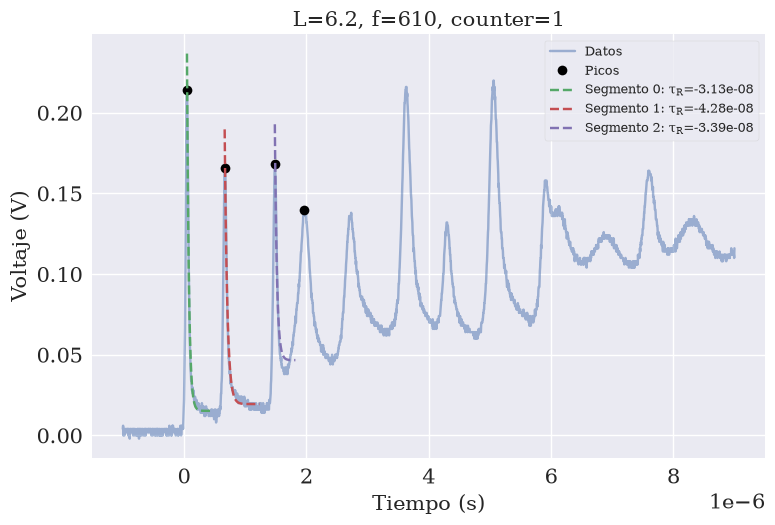

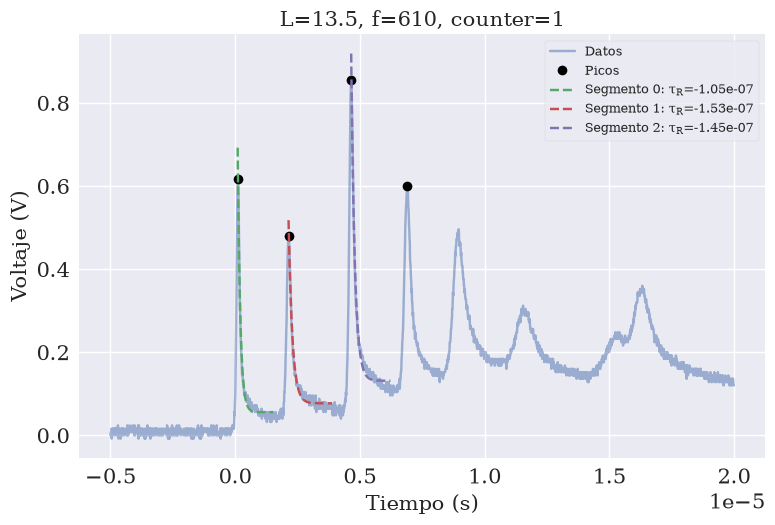

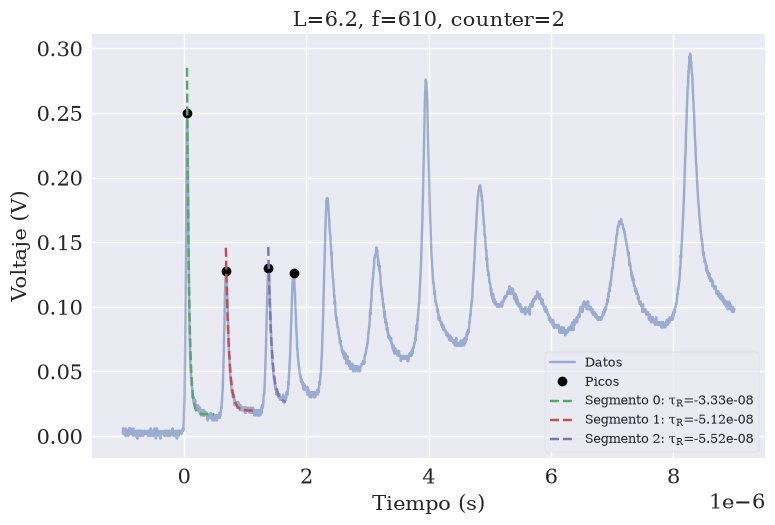

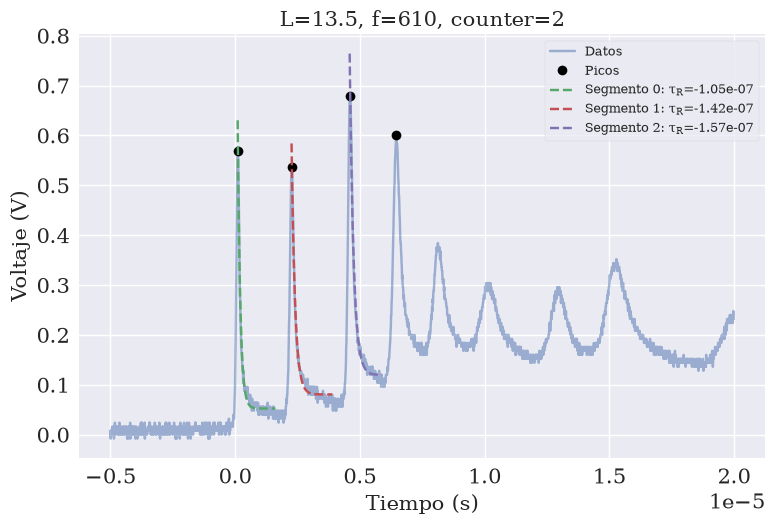

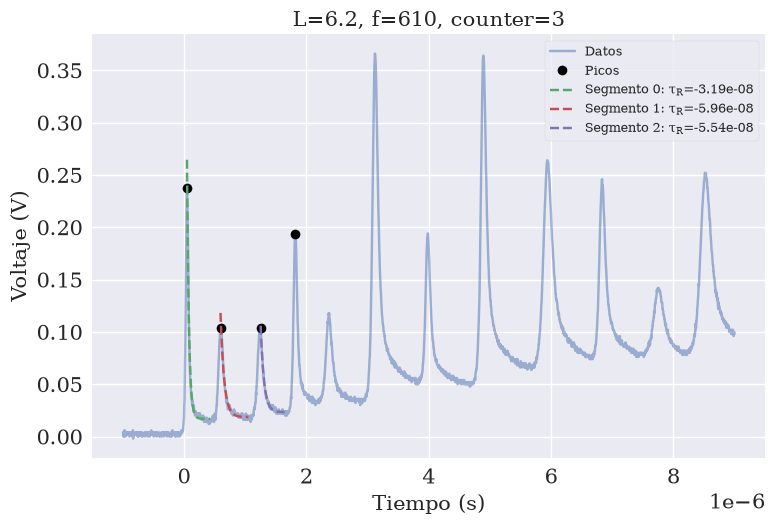

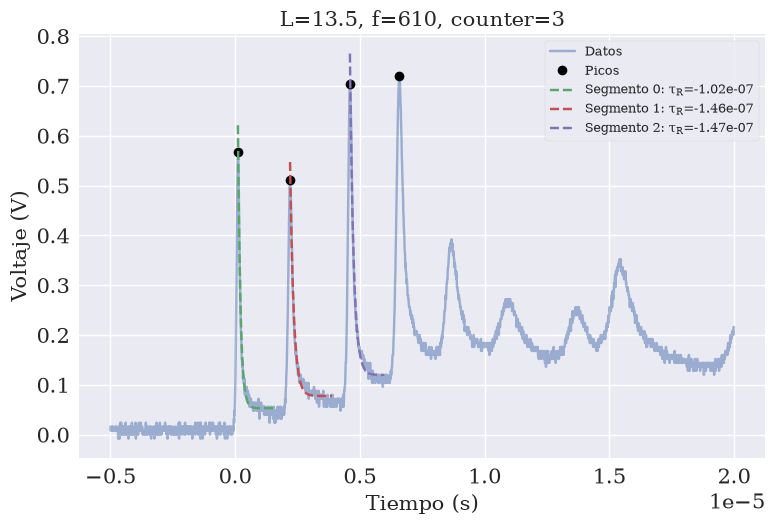

       L    f     p ventana  counter                                 archivo  \
0    6.2  610  2.38       s        1        laser_chopper_f610_p2.38_s_1.csv   
1    6.2  610  2.38       s        1        laser_chopper_f610_p2.38_s_1.csv   
2    6.2  610  2.38       s        1        laser_chopper_f610_p2.38_s_1.csv   
3   13.5  610  2.38       s        1  laser_chopper_L13.5_f610_p2.38_s_1.csv   
4   13.5  610  2.38       s        1  laser_chopper_L13.5_f610_p2.38_s_1.csv   
5   13.5  610  2.38       s        1  laser_chopper_L13.5_f610_p2.38_s_1.csv   
6    6.2  610  2.38       s        2        laser_chopper_f610_p2.38_s_2.csv   
7    6.2  610  2.38       s        2        laser_chopper_f610_p2.38_s_2.csv   
8    6.2  610  2.38       s        2        laser_chopper_f610_p2.38_s_2.csv   
9   13.5  610  2.38       s        2  laser_chopper_L13.5_f610_p2.38_s_2.csv   
10  13.5  610  2.38       s        2  laser_chopper_L13.5_f610_p2.38_s_2.csv   
11  13.5  610  2.38       s        2  la

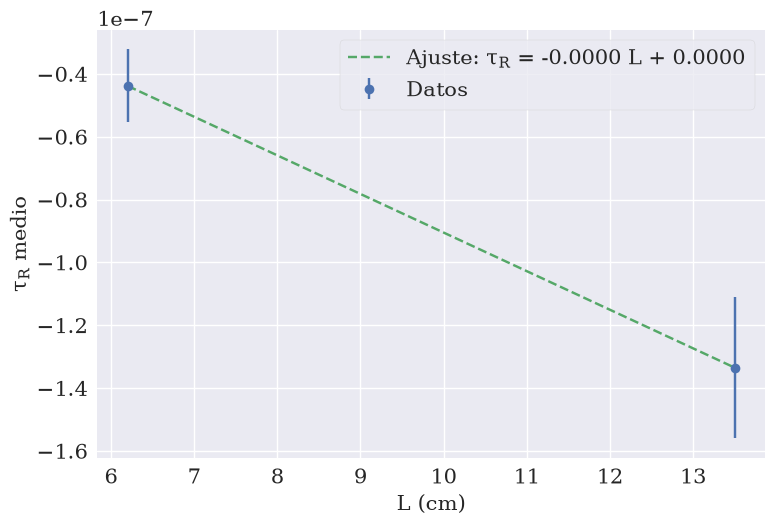


Pendiente: -1.2285869008998543e-08
Ordenada al origen: 3.233779410683944e-08
Tiempo de vida: 0.005429908190592439


In [37]:
# ---------------------------------------------------------------------------
# Lista de configuraciones a analizar. Cada dict define un archivo distinto.
# Pueden repetirse valores de L entre configs (distinto p, ventana, counter)
# ---------------------------------------------------------------------------
configs = np.concatenate([[
    {"L": 6.2,  "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 13.5, "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
    # {"L": 21.4, "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
    # {"L": 87.0,  "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
]for counter in range(1,4)])

N_SEGMENTOS = 3  # cantidad de segmentos (entre picos consecutivos) a ajustar
BUFFER_FRACTION = 0.3  # fracción del intervalo entre picos que se recorta antes del pico siguiente
 
FIND_PEAKS_KWARGS = dict(
    height=0.05,
    distance=40,
    prominence=0.05,
)
 
 
def nombre_archivo(cfg):
    L_text = f"_L{cfg['L']:.1f}" if cfg["L"] != 6.2 else ""
    return f"laser_chopper{L_text}_f{cfg['f']:.0f}_p{cfg['p']:.2f}_{cfg['ventana']}_{cfg['counter']}.csv"
 
 
def exponencial(t, A, tau_R, P_0):
    return P_0 + A * np.exp(t / tau_R)
 
 
def ajustar_segmento(t_seg, v_seg):
    """Ajusta e(t) = P_0 + A * exp(t / tau_R) a los datos crudos de un segmento entre dos picos consecutivos."""
    # estimación inicial: pendiente de log(v) vs t da 1/tau_R; P_0 arranca en 0
    p0_tau = (t_seg[-1] - t_seg[0]) / np.log(np.abs(v_seg[-1] / v_seg[0]))
    p0 = (v_seg[0], p0_tau, 0.0)
    (A, tau_R, P_0), _ = curve_fit(exponencial, t_seg, v_seg, p0=p0, maxfev=10000)
    return A, tau_R, P_0
 
 
# ---------------------------------------------------------------------------
# Loop principal: cargar cada archivo, encontrar los primeros N picos y
# ajustar la exponencial
# ---------------------------------------------------------------------------
resultados = []
 
for cfg in configs:
    ruta = "../datos/" + nombre_archivo(cfg)
    df = pd.read_csv(ruta)
 
    t = df["Tiempo"].to_numpy()
    v = df["VoltajeCH1"].to_numpy()
 
    idx_picos, _ = find_peaks(v, **FIND_PEAKS_KWARGS)
    if len(idx_picos) < N_SEGMENTOS + 1:
        print(
            f"Advertencia: {nombre_archivo(cfg)} tiene menos de {N_SEGMENTOS + 1} picos "
            f"(necesarios para {N_SEGMENTOS} segmentos), se omite."
        )
        continue
 
    idx_picos = idx_picos[: N_SEGMENTOS + 1]
    t_picos = t[idx_picos]
    v_picos = v[idx_picos]
 
    # -----------------------------------------------------------------
    # Ajustar cada segmento entre picos consecutivos (con buffer antes
    # del pico siguiente) y guardar los resultados
    # -----------------------------------------------------------------
    fig_i, ax_i = plt.subplots()
    ax_i.plot(t, v, alpha=0.5, label="Datos")
    ax_i.plot(t_picos, v_picos, "o", color="k", label="Picos")
 
    for i in range(N_SEGMENTOS):
        t0, t1 = t_picos[i], t_picos[i + 1]
        buffer = BUFFER_FRACTION * (t1 - t0)
        t1_efectivo = t1 - buffer
 
        mask = (t >= t0) & (t <= t1_efectivo)
        t_seg = t[mask]
        v_seg = v[mask]
 
        if len(t_seg) < 3:
            print(f"  Segmento {i} de {nombre_archivo(cfg)} tiene muy pocos puntos, se omite.")
            continue
 
        try:
            A, tau_R, P_0 = ajustar_segmento(t_seg, v_seg)
        except RuntimeError:
            print(f"  No convergió el ajuste del segmento {i} de {nombre_archivo(cfg)}.")
            continue
 
        t_fino = np.linspace(t_seg[0], t_seg[-1], 100)
        v_fino = exponencial(t_fino, A, tau_R, P_0)
        ax_i.plot(t_fino, v_fino, "--", label=f"Segmento {i}: $\\tau_R$={tau_R:.3g}")
 
        resultados.append(
            {
                "L": cfg["L"],
                "f": cfg["f"],
                "p": cfg["p"],
                "ventana": cfg["ventana"],
                "counter": cfg["counter"],
                "archivo": nombre_archivo(cfg),
                "segmento": i,
                "A": A,
                "tau_R": tau_R,
                "P_0": P_0,
            }
        )
 
    ax_i.set_xlabel("Tiempo (s)")
    ax_i.set_ylabel("Voltaje (V)")
    ax_i.set_title(f"L={cfg['L']}, f={cfg['f']}, counter={cfg['counter']}")
    ax_i.legend(fontsize=fontsize * 0.6)
    plt.tight_layout()
 
    nombre_base = nombre_archivo(cfg).replace(".csv", "")
    plt.show()
    plt.close(fig_i)
 
res_df = pd.DataFrame(resultados)
print(res_df)
 
if res_df.empty:
    raise RuntimeError("No se pudo ajustar tau_R en ningún archivo; revisar FIND_PEAKS_KWARGS o N_SEGMENTOS.")
 
# ---------------------------------------------------------------------------
# Promediar tau_R sobre todas las series (picos) que comparten el mismo L
# ---------------------------------------------------------------------------
promedios = (
    res_df.groupby("L")["tau_R"]
    .agg(tau_R_medio="mean", tau_R_std="std", n="count")
    .reset_index()
    .sort_values("L")
)
 
print("\ntau_R promedio por L:")
print(promedios)
 
# ---------------------------------------------------------------------------
# Ajuste lineal: tau_R_medio en función de L
# ---------------------------------------------------------------------------
L_arr = promedios["L"].to_numpy()
tau_arr = promedios["tau_R_medio"].to_numpy()
tau_err = promedios["tau_R_std"].fillna(0).to_numpy()
 
m, b = np.polyfit(L_arr, tau_arr, 1)
 
L_fit = np.linspace(L_arr.min(), L_arr.max(), 200)
tau_fit = m * L_fit + b
 
fig, ax = plt.subplots()
ax.errorbar(L_arr, tau_arr, yerr=tau_err, fmt="o", label="Datos", capsize=3)
ax.plot(L_fit, tau_fit, "--", label=f"Ajuste: $\\tau_R$ = {m:.4f} L + {b:.4f}")
ax.set_xlabel("L (cm)")
ax.set_ylabel(r"$\tau_R$ medio")
ax.legend()
plt.tight_layout()
plt.show()
 
print(f"\nPendiente: {m}")
print(f"Ordenada al origen: {b}")
c = 2.998e+10# cm/s
tau_c = -2/(c*m)
print(f"Tiempo de vida: {tau_c}")


       f    L     p ventana  counter                            archivo  v_max
0    186  6.2  2.38       s        1   laser_chopper_f186_p2.38_s_1.csv  0.104
1    305  6.2  2.38       s        1   laser_chopper_f305_p2.38_s_1.csv  0.172
2    610  6.2  2.38       s        1   laser_chopper_f610_p2.38_s_1.csv  0.220
3   1000  6.2  2.38       s        1  laser_chopper_f1000_p2.38_s_1.csv  0.384
4    186  6.2  2.38       s        2   laser_chopper_f186_p2.38_s_2.csv  0.092
5    305  6.2  2.38       s        2   laser_chopper_f305_p2.38_s_2.csv  0.224
6    610  6.2  2.38       s        2   laser_chopper_f610_p2.38_s_2.csv  0.296
7   1000  6.2  2.38       s        2  laser_chopper_f1000_p2.38_s_2.csv  0.412
8    186  6.2  2.38       s        3   laser_chopper_f186_p2.38_s_3.csv  0.096
9    305  6.2  2.38       s        3   laser_chopper_f305_p2.38_s_3.csv  0.236
10   610  6.2  2.38       s        3   laser_chopper_f610_p2.38_s_3.csv  0.366
11  1000  6.2  2.38       s        3  laser_chopper_

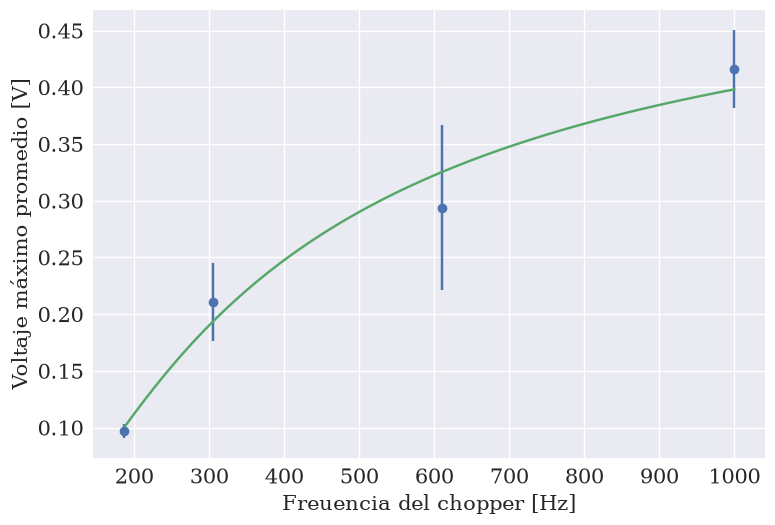

In [5]:
configs = np.concatenate([[
    {"L": 6.2,  "f": 186, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 6.2, "f": 305, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 6.2, "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
    {"L": 6.2, "f": 1000, "p": 2.38, "ventana": "s", "counter": counter},
] for counter in range(1, 4)])

def nombre_archivo(cfg):
    L_text = f"_L{cfg['L']:.1f}" if cfg["L"] != 6.2 else ""
    return f"laser_chopper{L_text}_f{cfg['f']:.0f}_p{cfg['p']:.2f}_{cfg['ventana']}_{cfg['counter']}.csv"

def exponencial_inv(f, A, f_0):
    return A * np.exp(-f_0/f)

# ---------------------------------------------------------------------------
# Loop principal: cargar cada archivo y calcular el voltaje máximo
# ---------------------------------------------------------------------------
resultados = []

for cfg in configs:
    ruta = "../datos/" + nombre_archivo(cfg)
    df = pd.read_csv(ruta)

    v_max = df["VoltajeCH1"].max()

    resultados.append(
        {
            "f": cfg["f"],
            "L": cfg["L"],
            "p": cfg["p"],
            "ventana": cfg["ventana"],
            "counter": cfg["counter"],
            "archivo": nombre_archivo(cfg),
            "v_max": v_max,
        }
    )

res_df = pd.DataFrame(resultados)
print(res_df)

# ---------------------------------------------------------------------------
# Promediar v_max sobre todas las corridas que comparten el mismo f
# ---------------------------------------------------------------------------
promedios = (
    res_df.groupby("f")["v_max"]
    .agg(v_max_medio="mean", v_max_std="std", n="count")
    .reset_index()
    .sort_values("f")
)

print("\nPromedio de voltaje máximo por frecuencia:")
print(promedios)

# ---------------------------------------------------------------------------
# Gráfico
# ---------------------------------------------------------------------------
fig, ax = plt.subplots()
ax.errorbar(
    promedios["f"],
    promedios["v_max_medio"],
    yerr=promedios["v_max_std"].fillna(0),
    fmt="o",
    capsize=3,
)
popt, pcov = curve_fit(exponencial_inv, promedios["f"], promedios["v_max_medio"])
fs = np.linspace(np.min(promedios["f"]), np.max(promedios["f"]), 100)
ax.plot(fs, exponencial_inv(fs, *popt), label=f"Ajuste: V = {popt[0]:.3f} f^{popt[1]:.3f}")
ax.set_xlabel("Freuencia del chopper [Hz]")
ax.set_ylabel("Voltaje máximo promedio [V]")

plt.tight_layout()
plt.show()

3 picos encontrados para p = 1.7 corrida 1


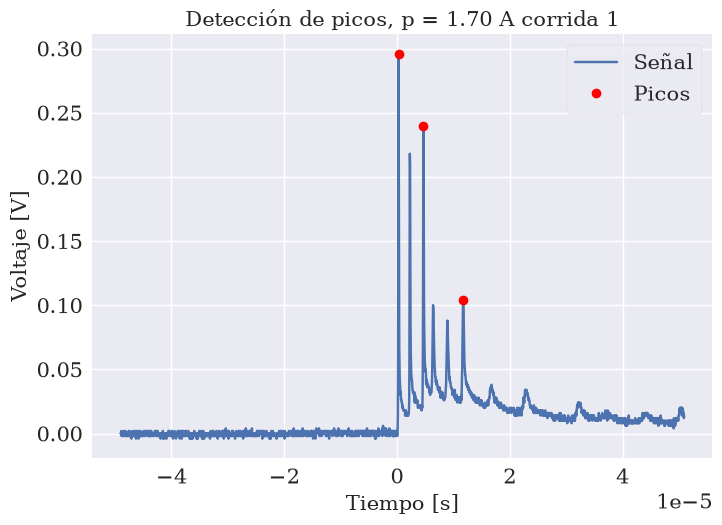

4 picos encontrados para p = 1.85 corrida 1


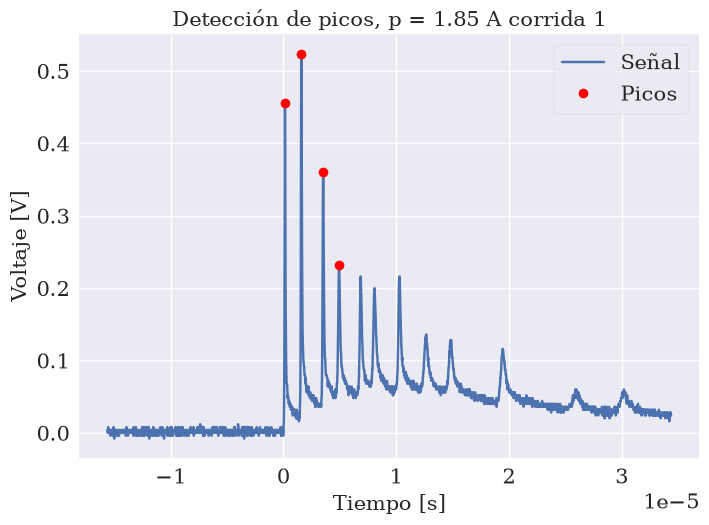

4 picos encontrados para p = 2.1 corrida 1


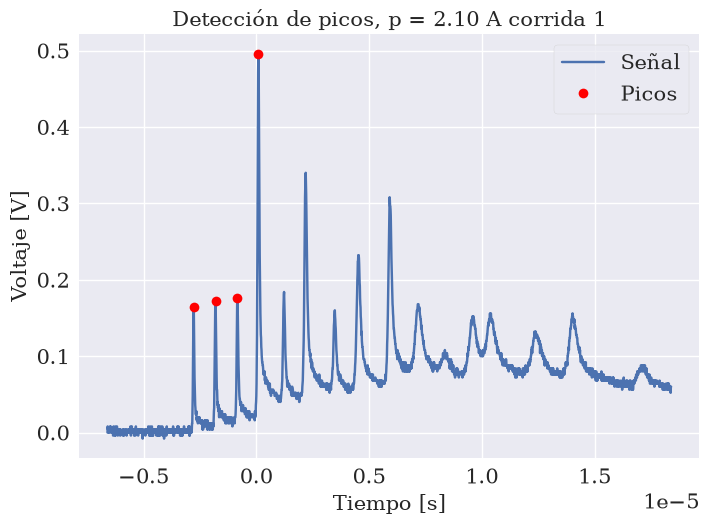

4 picos encontrados para p = 2.38 corrida 1


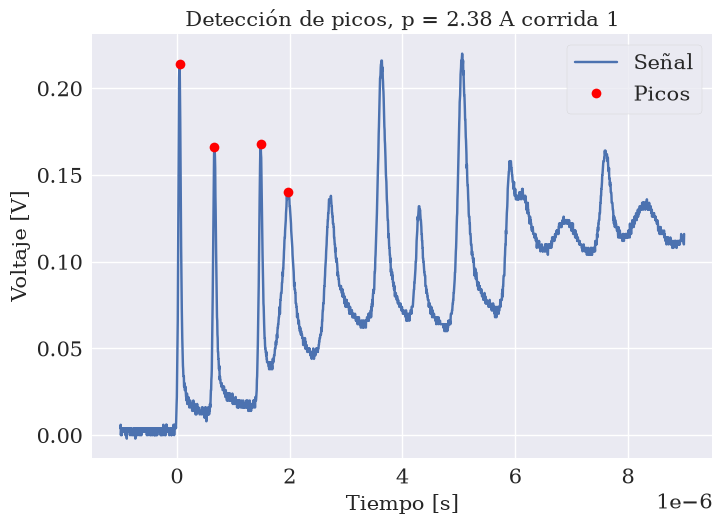

3 picos encontrados para p = 1.7 corrida 2


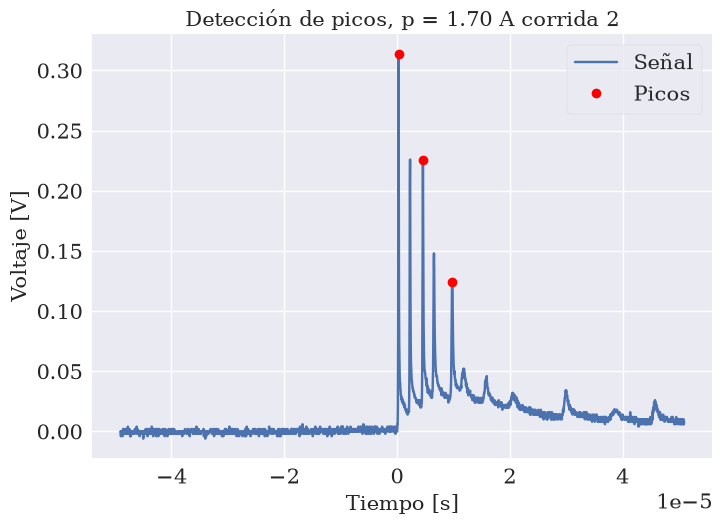

4 picos encontrados para p = 1.85 corrida 2


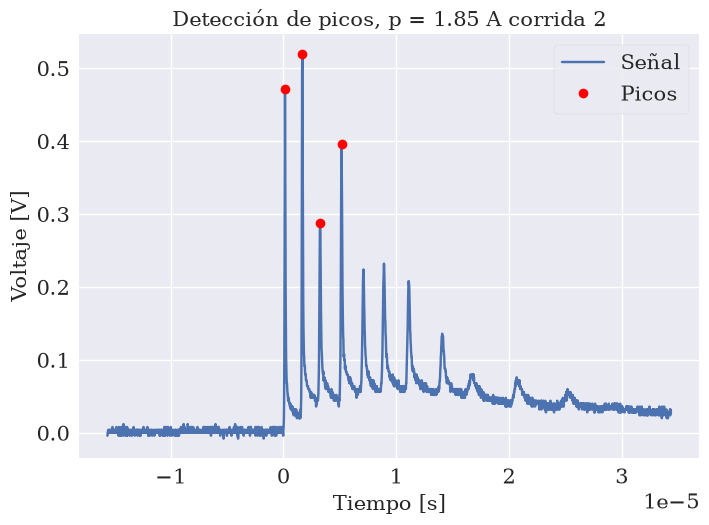

4 picos encontrados para p = 2.1 corrida 2


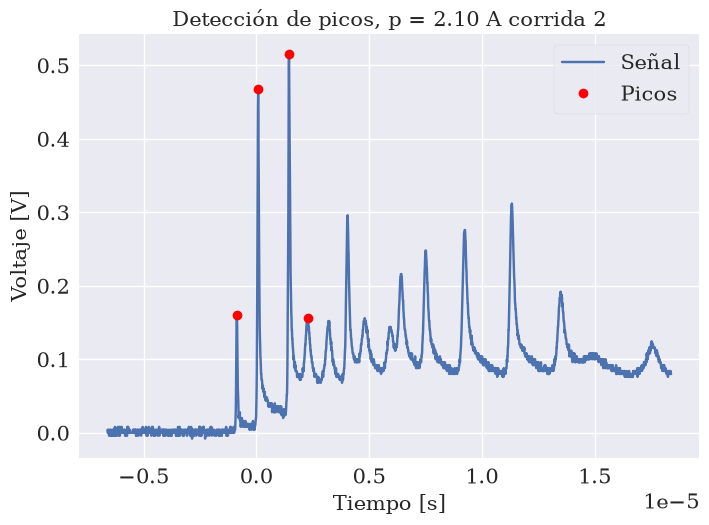

4 picos encontrados para p = 2.38 corrida 2


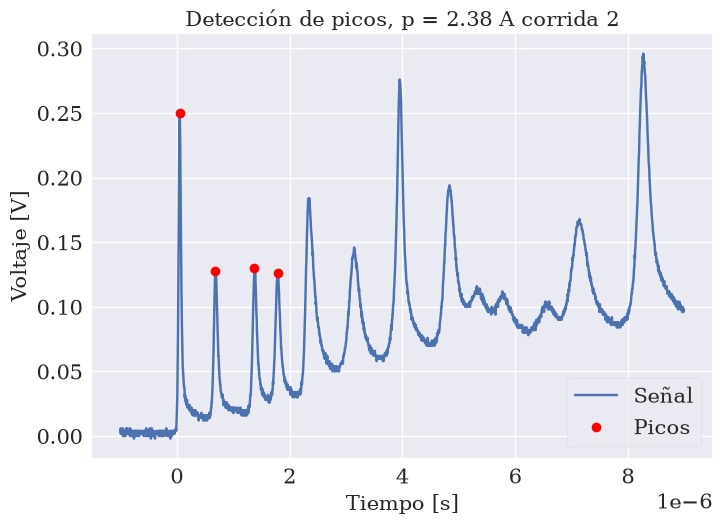

3 picos encontrados para p = 1.7 corrida 3


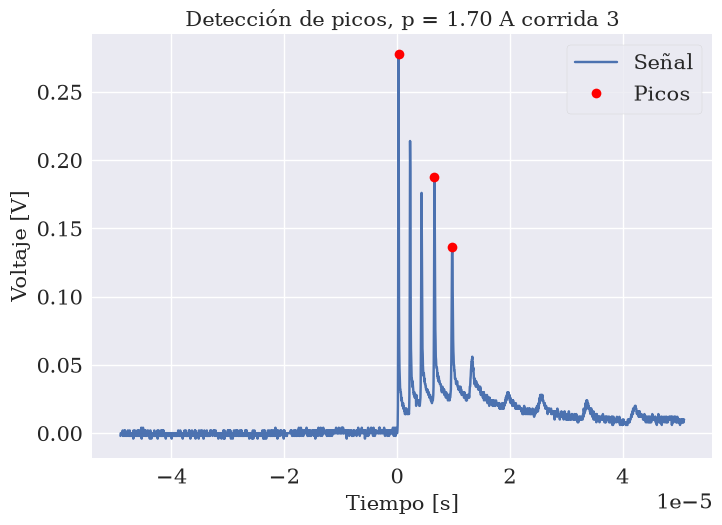

4 picos encontrados para p = 1.85 corrida 3


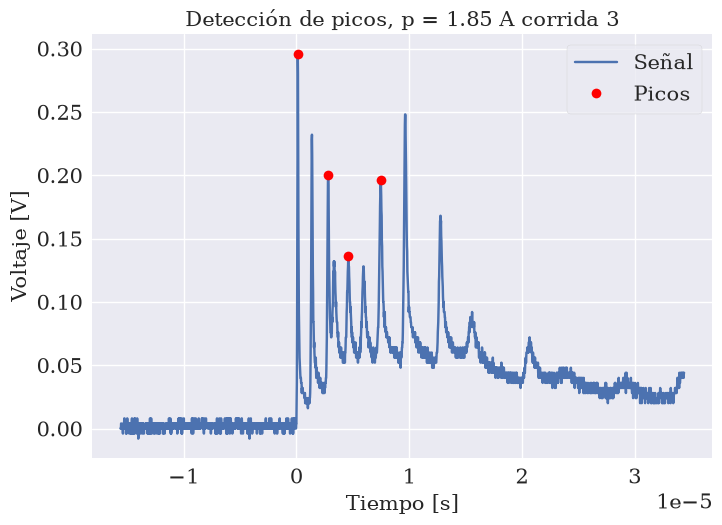

4 picos encontrados para p = 2.1 corrida 3


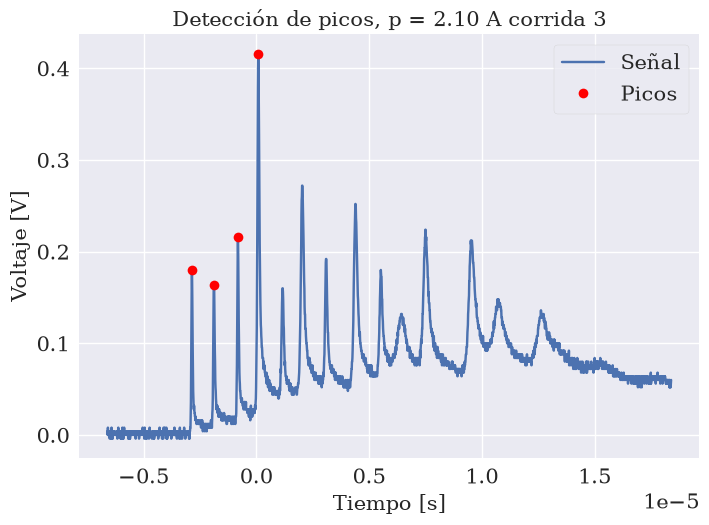

4 picos encontrados para p = 2.38 corrida 3


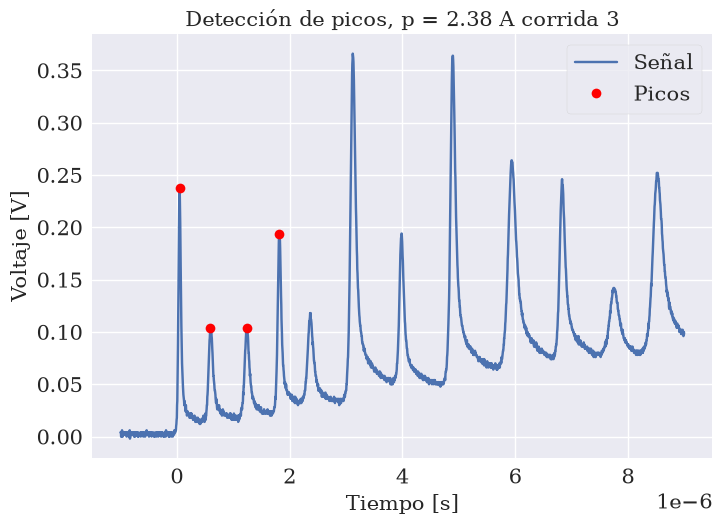

       p                           archivo      dt_medio        dt_std
0   1.70  laser_chopper_f610_p1.70_s_1.csv  5.720000e-06  1.320000e-06
1   1.85  laser_chopper_f610_p1.85_s_1.csv  1.600000e-06  2.268627e-07
2   2.10  laser_chopper_f610_p2.10_s_1.csv  9.566667e-07  1.885618e-08
3   2.38  laser_chopper_f610_p2.38_s_1.csv  6.413333e-07  1.367171e-07
4   1.70  laser_chopper_f610_p1.70_s_2.csv  4.760000e-06  4.400000e-07
5   1.85  laser_chopper_f610_p1.85_s_2.csv  1.673333e-06  1.611073e-07
6   2.10  laser_chopper_f610_p2.10_s_2.csv  1.043333e-06  2.361261e-07
7   2.38  laser_chopper_f610_p2.38_s_2.csv  5.813333e-07  1.191227e-07
8   1.70  laser_chopper_f610_p1.70_s_3.csv  4.760000e-06  1.600000e-06
9   1.85  laser_chopper_f610_p1.85_s_3.csv  2.446667e-06  4.759085e-07
10  2.10  laser_chopper_f610_p2.10_s_3.csv  9.833333e-07  6.128259e-08
11  2.38  laser_chopper_f610_p2.38_s_3.csv  5.893333e-07  4.030991e-08

Pendiente: 2116409.867600693
Ordenada al origen: -3396751.013542257


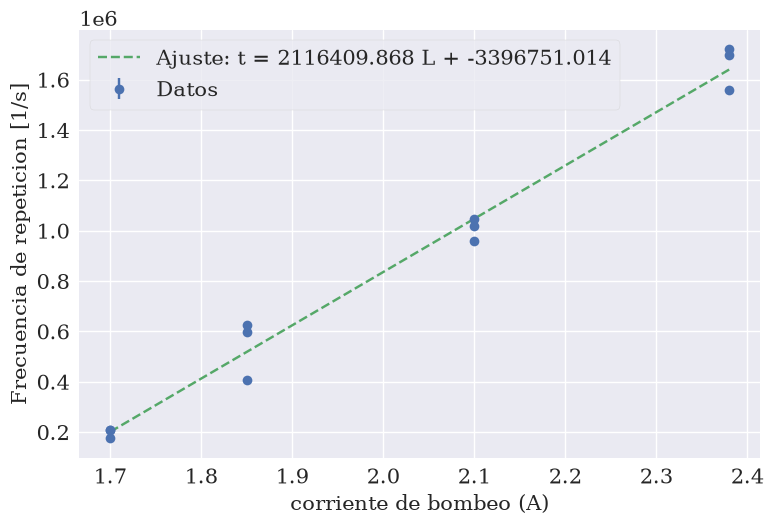

9.45e-09 m/s


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks 

configs = np.concatenate([[
    {"L": 6.2,  "f": 610, "p": 1.70, "ventana": "s", "counter": counter},
    {"L": 6.2, "f": 610, "p": 1.85, "ventana": "s", "counter": counter},
    {"L": 6.2, "f": 610, "p": 2.10, "ventana": "s", "counter": counter},
    {"L": 6.2, "f": 610, "p": 2.38, "ventana": "s", "counter": counter},
] for counter in range(1, 4)])

FIND_PEAKS_KWARGS = dict(
    height=None,
    distance=70,
    prominence=0.05,
)

PLOT_SERIES = True # plotear cada serie de tiempo y los picos detectados

N_PICOS = 4 # Tomar hasta los primeros N_PICOS picos de cada serie

def nombre_archivo(cfg):
    L_text = f"_L{cfg['L']:.1f}" if cfg["L"] != 6.2 else ""
    return f"laser_chopper{L_text}_f{cfg['f']:.0f}_p{cfg['p']:.2f}_{cfg['ventana']}_{cfg['counter']}.csv"


def tiempo_medio_entre_picos(t, v, L, counter, plot = False, **kwargs):
    """Encuentra los picos de v(t) y devuelve (dt_medio, dt_std) entre picos consecutivos."""
    idx_picos, _ = find_peaks(v, **kwargs)
    idx_picos = idx_picos[:N_PICOS]
    print(len(idx_picos), "picos encontrados para p =", L, "corrida", counter)
    if len(idx_picos) < 2:
        return np.nan, np.nan
    t_picos = t[idx_picos]
    dt = np.diff(t_picos)
    if plot:
        plt.plot(t, v, label="Señal")
        plt.plot(t_picos, v[idx_picos], "o", color = "red", label="Picos")
        plt.xlabel("Tiempo [s]")
        plt.ylabel("Voltaje [V]")
        plt.legend()
        plt.title(f"Detección de picos, p = {L:.2f} A corrida {counter}")
        plt.show()
    return dt.mean(), dt.std()


# ---------------------------------------------------------------------------
# Loop principal: cargar cada archivo y calcular el tiempo medio entre picos
# ---------------------------------------------------------------------------
resultados = []

for cfg in configs:
    ruta = "../datos/" + nombre_archivo(cfg)
    df = pd.read_csv(ruta)

    t = df["Tiempo"].to_numpy()
    v = df["VoltajeCH1"].to_numpy()

    dt_medio, dt_std = tiempo_medio_entre_picos(t, v, cfg["p"], cfg["counter"], plot = PLOT_SERIES, **FIND_PEAKS_KWARGS)

    resultados.append(
        {
            "p": cfg["p"],
            "archivo": nombre_archivo(cfg),
            "dt_medio": dt_medio,
            "dt_std": dt_std,
        }
    )

res_df = pd.DataFrame(resultados)
print(res_df)

res_df = res_df.dropna(subset=["dt_medio"])
if res_df.empty:
    raise RuntimeError("No se encontraron suficientes picos en ningún archivo; revisar FIND_PEAKS_KWARGS.")

# ---------------------------------------------------------------------------
# Ajuste lineal dt_medio en función de L
# ---------------------------------------------------------------------------
L_arr = res_df["p"].to_numpy()
time_arr = res_df["dt_medio"].to_numpy()
time_err = res_df["dt_std"].to_numpy() 

m, b = np.polyfit(L_arr, 1/time_arr, 1)

L_fit = np.linspace(L_arr.min(), L_arr.max(), 200)
time_fit = m * L_fit + b

fig, ax = plt.subplots()
ax.errorbar(L_arr, 1/time_arr, yerr=time_err, fmt="o", label="Datos", capsize=3)
ax.plot(L_fit, time_fit, "--", label=f"Ajuste: t = {m:.3f} L + {b:.3f}")
ax.set_xlabel("corriente de bombeo (A)")
ax.set_ylabel("Frecuencia de repeticion [1/s]")
ax.legend()
plt.tight_layout()

print(f"\nPendiente: {m}")
print(f"Ordenada al origen: {b}")
plt.show()

c = 2/m / 100
print(f"{c:.2e} m/s")